In [3]:
import os
os.environ.setdefault("BCD_DATA_FOLDER", "/data/gaetane")  # adapte si besoin

import torch
import matplotlib.pyplot as plt
import numpy as np

from dataloader import HiUCD_Dataset 
from encoder import DinoV2Encoder
from encoder import ChangeDetectionModel
from encoder import FeatureTransformer

In [4]:
ds_train = HiUCD_Dataset(cropsize=256, type="train", everything=True)

image1, image2, changemap, changemap2, landcover1, landcover2 = ds_train[9]

print("image1:", image1.shape, image1.dtype, image1.min().item(), image1.max().item())
print("image2:", image2.shape, image2.dtype, image2.min().item(), image2.max().item())
print("changemap:", changemap.shape, changemap.dtype, torch.unique(changemap))
print("landcover1:", landcover1.shape, landcover1.dtype, torch.unique(landcover1))
print("landcover2:", landcover2.shape, landcover2.dtype, torch.unique(landcover2))

image1: torch.Size([3, 256, 256]) torch.float32 0.0470588244497776 1.0
image2: torch.Size([3, 256, 256]) torch.float32 0.0 1.0
changemap: torch.Size([256, 256]) torch.int32 tensor([0], dtype=torch.int32)
landcover1: torch.Size([256, 256]) torch.int64 tensor([2, 3, 5])
landcover2: torch.Size([256, 256]) torch.int64 tensor([2, 3, 5])


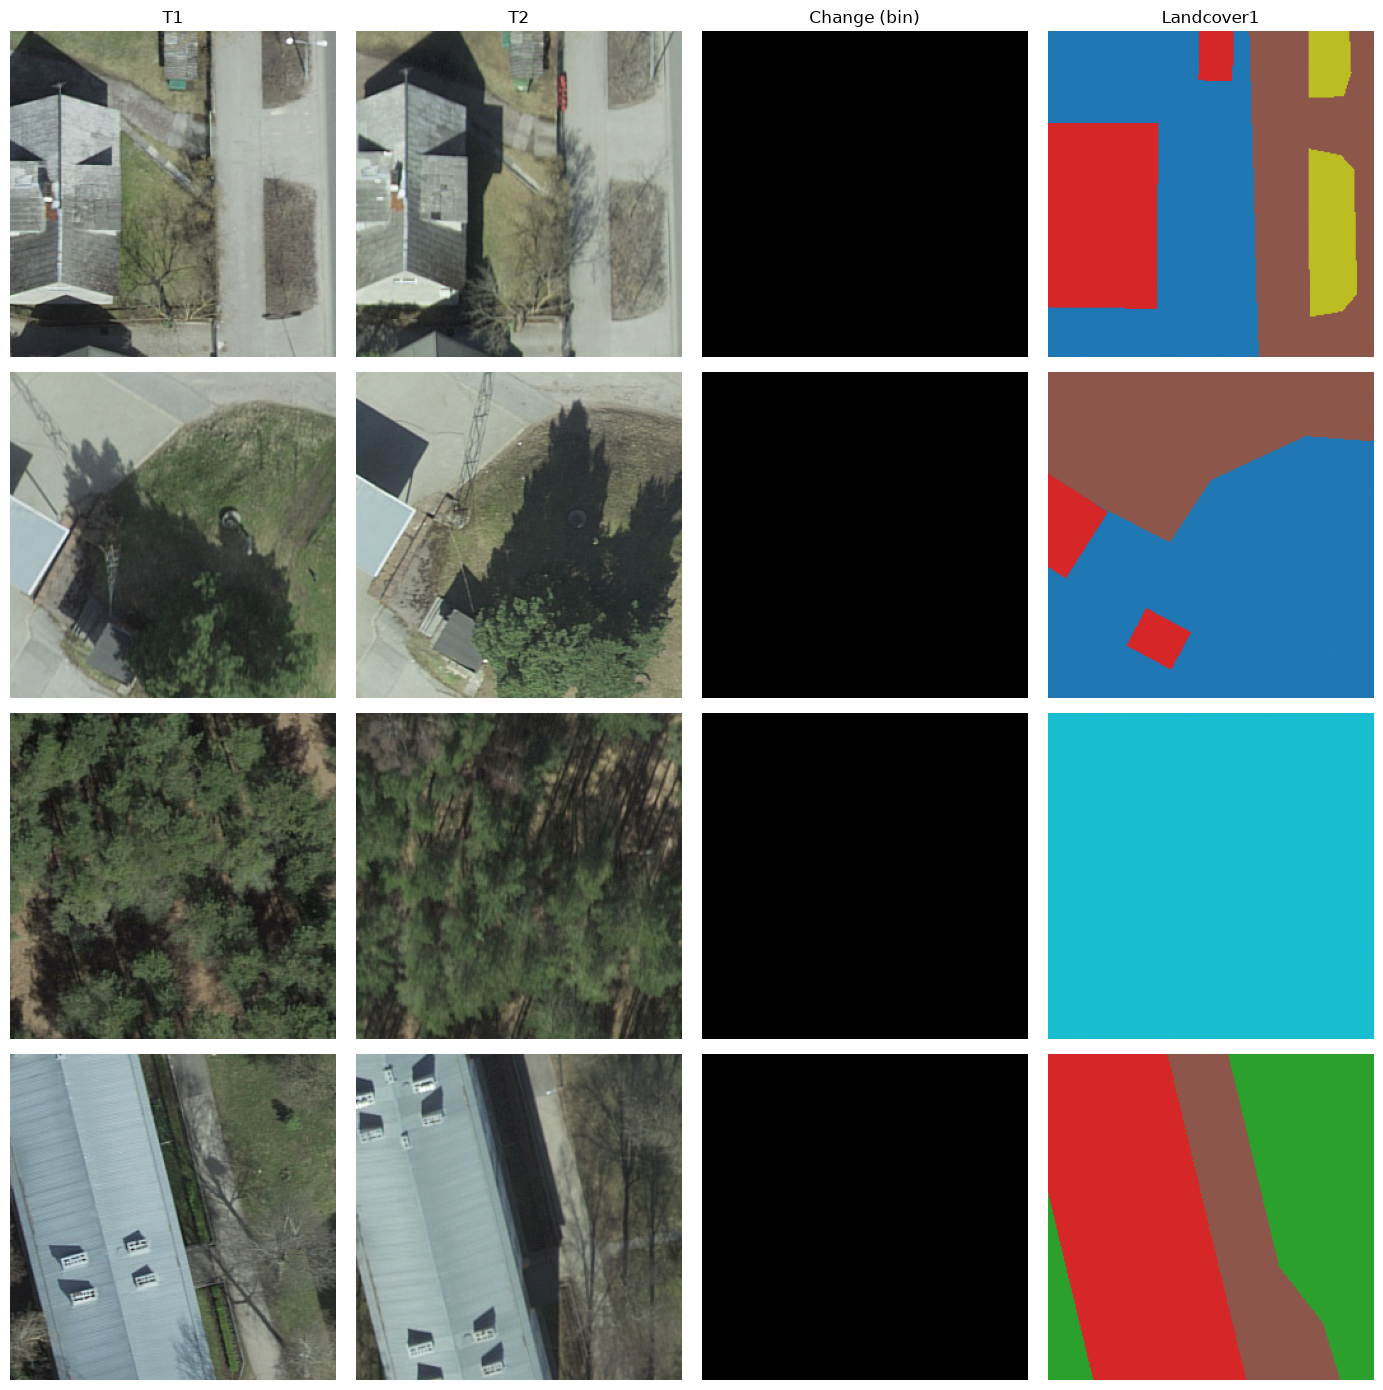

In [6]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_train, batch_size=4, shuffle=True)
image1, image2, changemap, _, landcover1, landcover2 = next(iter(loader))

fig, axs = plt.subplots(4, 4, figsize=(14, 14))
titles = ["T1", "T2", "Change (bin)", "Landcover1"]
for i in range(4):
    axs[i, 0].imshow(image1[i].permute(1, 2, 0))
    axs[i, 1].imshow(image2[i].permute(1, 2, 0))
    axs[i, 2].imshow(changemap[i], cmap="gray", vmin=0, vmax=1)
    axs[i, 3].imshow(landcover1[i], cmap="tab10", vmin=0, vmax=9)
    for j in range(4):
        axs[i, j].axis("off")
        if i == 0:
            axs[i, j].set_title(titles[j])
plt.tight_layout()
plt.show()


## Vérification encodeur 


check forward

In [13]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6)
model = ChangeDetectionModel(encoder, transformer)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch, im2_batch = im1.unsqueeze(0), im2.unsqueeze(0)

x_hat, y = model(im1_batch, im2_batch)
print("x_hat:", x_hat.shape, x_hat.requires_grad)
print("y:", y.shape, y.requires_grad)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


x_hat: torch.Size([1, 384, 16, 16]) True
y: torch.Size([1, 384, 16, 16]) False


x_hat a bien un gradient y n'en a pas

overfit sur un batch

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


pos_embed dans l'optimizer : True
[identity] baseline = 3.8821 | std par token de la cible = 2.361
step    0 | loss 5.818254 | loss/baseline 1.4988 | grad norm 6.1587
step   50 | loss 1.993859 | loss/baseline 0.5136 | grad norm 1.4951
step  100 | loss 1.827641 | loss/baseline 0.4708 | grad norm 0.6177
step  150 | loss 1.743705 | loss/baseline 0.4492 | grad norm 0.9119
step  200 | loss 1.672489 | loss/baseline 0.4308 | grad norm 0.3505
step  250 | loss 1.621838 | loss/baseline 0.4178 | grad norm 1.3473
step  300 | loss 1.560031 | loss/baseline 0.4019 | grad norm 0.8962
step  350 | loss 1.502234 | loss/baseline 0.3870 | grad norm 0.3813
step  400 | loss 1.450947 | loss/baseline 0.3738 | grad norm 0.2971
step  450 | loss 1.402733 | loss/baseline 0.3613 | grad norm 0.4643
step  500 | loss 1.355807 | loss/baseline 0.3492 | grad norm 0.4613
step  550 | loss 1.309800 | loss/baseline 0.3374 | grad norm 0.3047
step  600 | loss 1.267777 | loss/baseline 0.3266 | grad norm 0.5557
step  650 | loss 

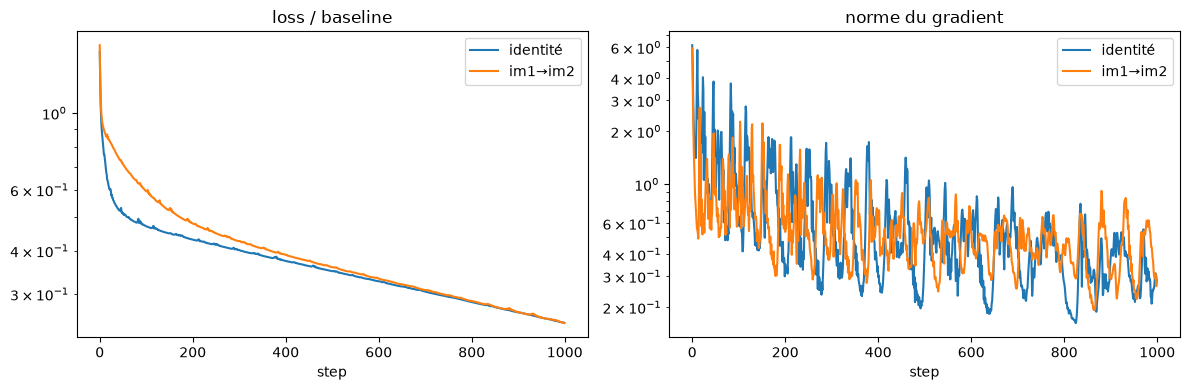

In [ ]:


# batch fixe de 4 images, le même pour tous les tests
torch.manual_seed(0)
loader = DataLoader(ds_train, batch_size=4, shuffle=True)
im1_fixed, im2_fixed, *_ = next(iter(loader))

# encodeur créé une seule fois (gelé, pas besoin de le recréer)
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)


def overfit(target_mode="identity", steps=1000, lr=3e-4):
    torch.manual_seed(0)
    transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6, dropout=0.0)
    model = ChangeDetectionModel(encoder, transformer)
    model.transformer.train()

    params = list(model.transformer.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)
    loss_fn = torch.nn.MSELoss()

    # vérif : pos_embed est bien dans l'optimizer
    opt_ids = {id(p) for g in optimizer.param_groups for p in g["params"]}
    print("pos_embed dans l'optimizer :", id(transformer.pos_embed) in opt_ids)

    # cible fixe et baseline
    with torch.no_grad():
        x_in = encoder(im1_fixed)
        y = x_in.clone() if target_mode == "identity" else encoder(im2_fixed)
        baseline = ((y - y.mean(dim=(0, 2, 3), keepdim=True)) ** 2).mean().item()
        y_std = y.permute(0, 2, 3, 1).reshape(-1, y.shape[1]).std(dim=1).mean().item()
    print(f"[{target_mode}] baseline = {baseline:.4f} | std par token de la cible = {y_std:.3f}")

    losses, gnorms = [], []
    for step in range(steps):
        optimizer.zero_grad()
        x_hat = model.transformer(x_in)
        loss = loss_fn(x_hat, y)
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(params, float("inf")).item()
        optimizer.step()
        losses.append(loss.item())
        gnorms.append(gn)
        if step % 50 == 0 or step == steps - 1:
            print(f"step {step:4d} | loss {loss.item():.6f} | loss/baseline {loss.item()/baseline:.4f} | grad norm {gn:.4f}")

    with torch.no_grad():
        x_hat = model.transformer(x_in)
        x_std = x_hat.permute(0, 2, 3, 1).reshape(-1, x_hat.shape[1]).std(dim=1).mean().item()
    print(f"std par token de x_hat à la fin = {x_std:.3f} (cible : {y_std:.3f})\n")
    return losses, gnorms, baseline


# 1) identité : doit converger vers ~0
l_id, g_id, b_id = overfit("identity")

# 2) im1 -> im2
l_im2, g_im2, b_im2 = overfit("im2")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for l, g, b, name in [(l_id, g_id, b_id, "identité"), (l_im2, g_im2, b_im2, "im1→im2")]:
    ax[0].plot([v / b for v in l], label=name)
    ax[1].plot(g, label=name)
ax[0].set_yscale("log"); ax[0].set_title("loss / baseline"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].set_yscale("log"); ax[1].set_title("norme du gradient"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

In [15]:
# le gradient circule-t-il dans tous les blocs ?
torch.manual_seed(0)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6, dropout=0.0)
model = ChangeDetectionModel(encoder, transformer)

x_hat, y = model(im1_fixed, im2_fixed)
loss = torch.nn.functional.mse_loss(x_hat, y)
loss.backward()

for name, p in transformer.named_parameters():
    g = p.grad.norm().item() if p.grad is not None else None
    print(f"{name}: grad_norm={g}")

transformer.zero_grad()

NameError: name 'im1_fixed' is not defined

In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score
import torch.nn.functional as F
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
@torch.no_grad()
def evaluate(loader, encoder, transformer):
    encoder.to(device); transformer.to(device); transformer.eval()
    raw_s, mod_s, labels = [], [], []
    for im1, im2, cm, *_ in loader:
        im1, im2 = im1.to(device), im2.to(device)
        x, y = encoder(im1), encoder(im2)
        x_hat = transformer(x)
        for pred, store in [(x, raw_s), (x_hat, mod_s)]:
            err = ((pred - y) ** 2).mean(dim=1, keepdim=True)              # (B,1,16,16)
            err = F.interpolate(err, size=cm.shape[-2:], mode="bilinear", align_corners=False)
            store.append(err.flatten().cpu())
        labels.append(cm.flatten().cpu())
    l = torch.cat(labels).numpy()
    out = {}
    for name, s in [("diff brute", raw_s), ("modèle", mod_s)]:
        s = torch.cat(s).numpy()
        out[name] = dict(AUROC=roc_auc_score(l, s), AP=average_precision_score(l, s))
    out["part de pixels changés"] = float(l.mean())
    return out

val_ds = HiUCD_Dataset(cropsize=256, type="val", everything=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

In [10]:
train_loader = DataLoader(ds_train, batch_size=16, shuffle=True, num_workers=4, drop_last=True)
torch.manual_seed(0)
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224).to(device)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6, dropout=0.1).to(device)

epochs = 20
opt = torch.optim.AdamW(transformer.parameters(), lr=3e-4, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4,
                                            total_steps=epochs * len(train_loader), pct_start=0.1)

for ep in range(epochs):
    transformer.train()
    tot = 0.0
    for im1, im2, *_ in train_loader:
        im1, im2 = im1.to(device), im2.to(device)
        with torch.no_grad():
            x, y = encoder(im1), encoder(im2)
        loss = F.mse_loss(transformer(x), y)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        tot += loss.item()
    print(f"epoch {ep}: train loss {tot/len(train_loader):.4f} | val {evaluate(val_loader, encoder, transformer)}")

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main
/home/gaetane/pdseceo/src/encoder.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_encoder_layers)
/home/gaetane/pdseceo/src/encoder.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=n_decoder_layers)


epoch 0: train loss 6.3635 | val {'diff brute': {'AUROC': 0.8520555656122449, 'AP': 0.2782234304582103}, 'modèle': {'AUROC': 0.8592190093124102, 'AP': 0.2672280353938264}, 'part de pixels changés': 0.0461738715737553}
epoch 1: train loss 5.1358 | val {'diff brute': {'AUROC': 0.7940485921944309, 'AP': 0.1876137422839959}, 'modèle': {'AUROC': 0.7942529039674215, 'AP': 0.17291786023904138}, 'part de pixels changés': 0.05141901565810381}
epoch 2: train loss 4.4837 | val {'diff brute': {'AUROC': 0.8267983823125276, 'AP': 0.2974640686230019}, 'modèle': {'AUROC': 0.8503995337186157, 'AP': 0.3198815643915932}, 'part de pixels changés': 0.07728369761321505}
epoch 3: train loss 4.0663 | val {'diff brute': {'AUROC': 0.8262477290273429, 'AP': 0.15127137389660078}, 'modèle': {'AUROC': 0.808853420140409, 'AP': 0.12370886011622588}, 'part de pixels changés': 0.0379020561606197}
epoch 4: train loss 3.9511 | val {'diff brute': {'AUROC': 0.825563547432719, 'AP': 0.30297619119118707}, 'modèle': {'AUROC':